# TF-IDF Baseline — Customer Support Ticket Classification

**Задача:** многоклассовая классификация по трём целевым переменным:
- `queue` — 52 класса (основная задача)
- `priority` — 5 классов
- `type` — 5 классов + Unknown

**Метрика:** `Score = 0.70·MacroF1(queue) + 0.15·Acc(priority) + 0.15·Acc(type)`

**Фичи:** `concat(subject, ' [SEP] ', body)` → TF-IDF  
**Модели:** LogisticRegression, LinearSVC, SGDClassifier(log_loss)

In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix
)

REPO_ROOT = Path('.')
PLOTS_DIR = REPO_ROOT / 'plots'
MODELS_DIR = REPO_ROOT / 'models'
PLOTS_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)

print('Libraries loaded OK')

Libraries loaded OK


## 1. Загрузка данных и сплиты

In [2]:
ds = load_dataset('Tobi-Bueck/customer-support-tickets')['train']
df = ds.to_pandas()
df['type'] = df['type'].fillna('Unknown')

print(f'Total rows: {len(df)}')
print(f'Columns: {list(df.columns)}')

Total rows: 61765
Columns: ['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8']


In [3]:
def read_idx(path):
    return np.loadtxt(path, dtype=np.int64)

splits = {}
for name in ('train', 'val', 'test'):
    idx = read_idx(REPO_ROOT / 'data' / f'{name}_idx.txt')
    splits[name] = df.iloc[idx].copy()
    print(f'{name}: {len(splits[name])} rows')

train: 49412 rows
val: 6176 rows
test: 6177 rows


## 2. Построение TF-IDF признаков

Конкатенируем `subject + ' [SEP] ' + body` как входной текст.

In [4]:
def make_text(d):
    return (d['subject'].fillna('') + ' [SEP] ' + d['body'].fillna('')).astype(str)

X_train_raw = make_text(splits['train'])
X_val_raw   = make_text(splits['val'])
X_test_raw  = make_text(splits['test'])

vectorizer = TfidfVectorizer(
    max_features=100_000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    analyzer='word'
)

Xtr  = vectorizer.fit_transform(X_train_raw)
Xval = vectorizer.transform(X_val_raw)
Xte  = vectorizer.transform(X_test_raw)

print(f'Vocab size : {Xtr.shape[1]}')
print(f'Train shape: {Xtr.shape}')
print(f'Val shape  : {Xval.shape}')
print(f'Test shape : {Xte.shape}')

Vocab size : 100000
Train shape: (49412, 100000)
Val shape  : (6176, 100000)
Test shape : (6177, 100000)


## 3. Сравнение моделей на Validation — Queue (52 класса)

In [5]:
y_train_q = splits['train']['queue'].astype(str).values
y_val_q   = splits['val']['queue'].astype(str).values

models = {
    'LogisticRegression': LogisticRegression(
        C=5, max_iter=1000, solver='lbfgs', multi_class='multinomial', n_jobs=-1
    ),
    'LinearSVC': LinearSVC(
        C=0.5, max_iter=2000
    ),
    'SGDClassifier': SGDClassifier(
        loss='log_loss', max_iter=1000, random_state=42, n_jobs=-1, tol=1e-3
    ),
}

val_preds_q = {}
val_metrics_q = []

for name, clf in models.items():
    print(f'Fitting {name}...', end=' ', flush=True)
    clf.fit(Xtr, y_train_q)
    pred = clf.predict(Xval)
    val_preds_q[name] = pred

    mf1  = f1_score(y_val_q, pred, average='macro',    zero_division=0)
    wf1  = f1_score(y_val_q, pred, average='weighted', zero_division=0)
    acc  = accuracy_score(y_val_q, pred)
    val_metrics_q.append({'Model': name, 'MacroF1': mf1, 'WeightedF1': wf1, 'Accuracy': acc})
    print(f'macro_f1={mf1:.4f}  weighted_f1={wf1:.4f}  acc={acc:.4f}')

metrics_q_df = pd.DataFrame(val_metrics_q).set_index('Model')
metrics_q_df

Fitting LogisticRegression... macro_f1=0.8617  weighted_f1=0.6428  acc=0.6473
Fitting LinearSVC... macro_f1=0.8845  weighted_f1=0.6596  acc=0.6634
Fitting SGDClassifier... macro_f1=0.2990  weighted_f1=0.3168  acc=0.3716


,MacroF1,WeightedF1,Accuracy
Model,,,
LogisticRegression,0.861676,0.642779,0.647345
LinearSVC,0.884495,0.659551,0.663374
SGDClassifier,0.299028,0.316828,0.371600


In [6]:
best_model_name_q = metrics_q_df['MacroF1'].idxmax()
best_clf_q = models[best_model_name_q]
print(f'Best model for queue: {best_model_name_q}  (MacroF1={metrics_q_df.loc[best_model_name_q, "MacroF1"]:.4f})')

Best model for queue: LinearSVC  (MacroF1=0.8845)


## 4. Confusion Matrix — Топ-20 классов по числу ошибок

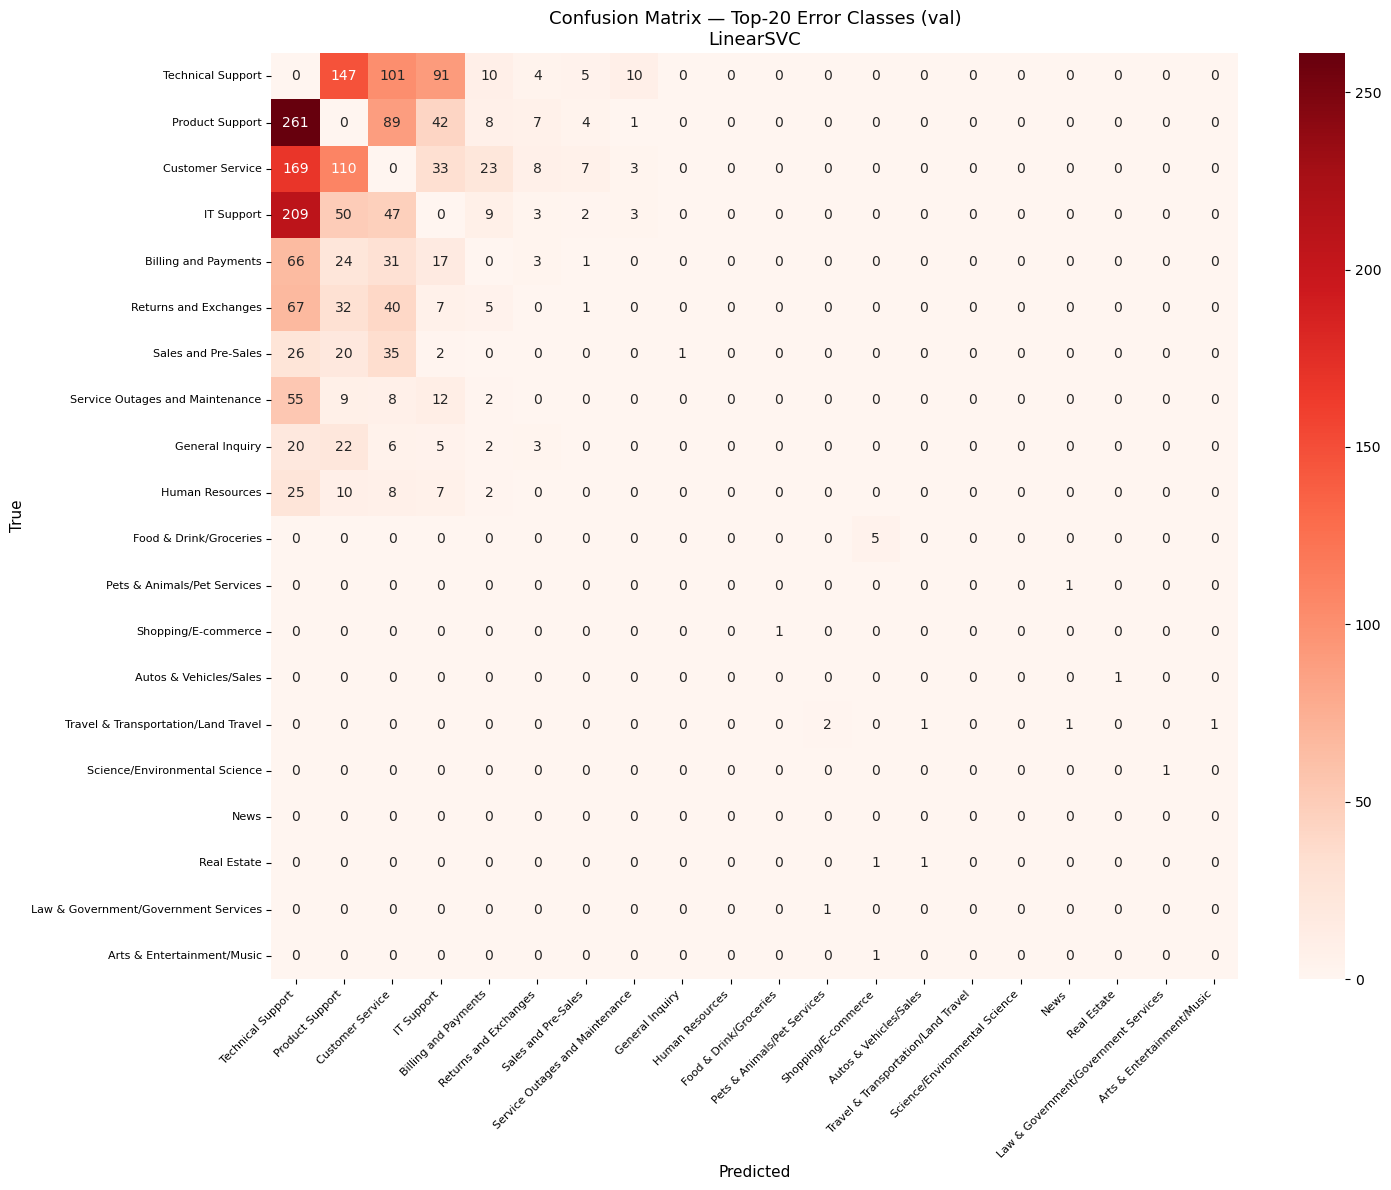

In [7]:
y_val_pred_best = val_preds_q[best_model_name_q]
labels_all = np.array(sorted(set(y_val_q) | set(y_val_pred_best)))

cm_full = confusion_matrix(y_val_q, y_val_pred_best, labels=labels_all)
cm_errors = cm_full.copy()
np.fill_diagonal(cm_errors, 0)

errors_per_class = cm_errors.sum(axis=1) + cm_errors.sum(axis=0)
top20_idx = np.argsort(errors_per_class)[-20:][::-1]
top20_labels = labels_all[top20_idx]

cm20 = confusion_matrix(y_val_q, y_val_pred_best, labels=top20_labels)
np.fill_diagonal(cm20, 0)

fig, ax = plt.subplots(figsize=(15, 12))
sns.heatmap(
    cm20,
    xticklabels=top20_labels,
    yticklabels=top20_labels,
    annot=True, fmt='d', cmap='Reds', ax=ax
)
ax.set_title(f'Confusion Matrix — Top-20 Error Classes (val)\n{best_model_name_q}', fontsize=13)
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('True', fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
fig.savefig(PLOTS_DIR / f'cm_top20_{best_model_name_q}_val.png', dpi=120)
plt.show()

## 5. Топ-20 самых сложных классов (низкий per-class F1)

In [8]:
report_dict = classification_report(
    y_val_q, y_val_pred_best, output_dict=True, zero_division=0
)

per_class_rows = []
for cls, d in report_dict.items():
    if cls in ('accuracy', 'macro avg', 'weighted avg'):
        continue
    per_class_rows.append({
        'class': cls,
        'F1': round(d['f1-score'], 4),
        'Precision': round(d['precision'], 4),
        'Recall': round(d['recall'], 4),
        'Support': int(d['support'])
    })

hardest_df = (
    pd.DataFrame(per_class_rows)
    .sort_values('F1')
    .head(20)
    .reset_index(drop=True)
)
hardest_df.to_csv(PLOTS_DIR / f'hardest_classes_{best_model_name_q}.csv', index=False)
print(f'Saved → plots/hardest_classes_{best_model_name_q}.csv')
hardest_df

Saved → plots/hardest_classes_LinearSVC.csv


,class,F1,Precision,Recall,Support
0,General Inquiry,0.3371,0.9375,0.2055,73
1,Sales and Pre-Sales,0.4348,0.6667,0.3226,124
2,IT Support,0.4410,0.4965,0.3966,537
3,Returns and Exchanges,0.4915,0.7565,0.3640,239
4,Customer Service,0.5245,0.5204,0.5287,749
5,Product Support,0.5303,0.5268,0.5339,884
6,Human Resources,0.6119,1.0000,0.4409,93
7,Technical Support,0.6230,0.5381,0.7397,1414
8,Service Outages and Maintenance,0.6771,0.8640,0.5567,194
9,Billing and Payments,0.7737,0.8505,0.7096,489


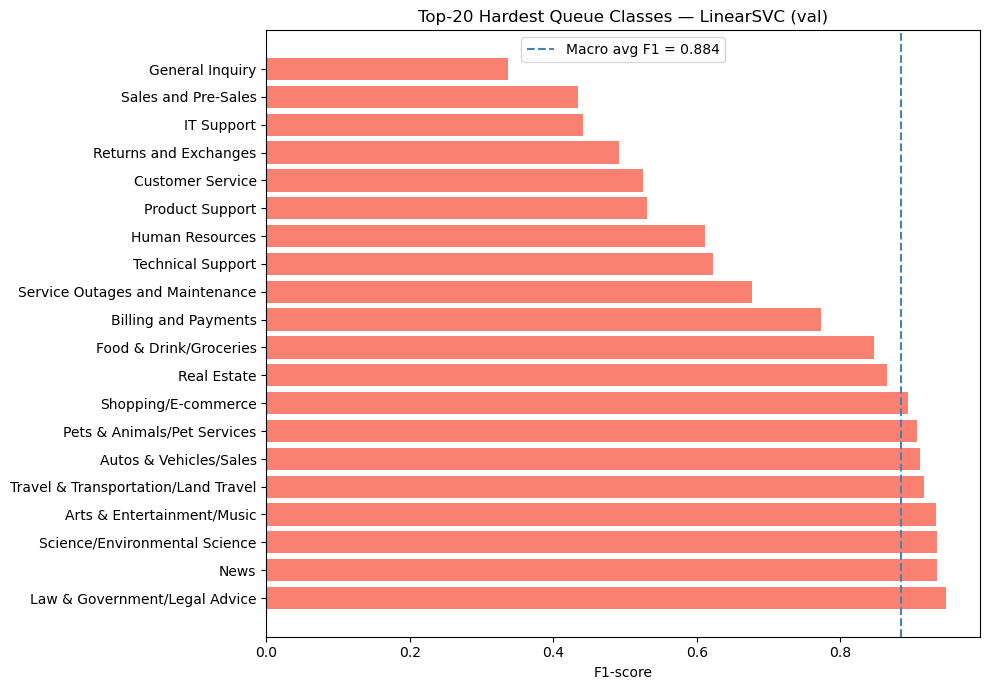

In [9]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(hardest_df['class'][::-1], hardest_df['F1'][::-1], color='salmon')
ax.set_xlabel('F1-score')
ax.set_title(f'Top-20 Hardest Queue Classes — {best_model_name_q} (val)')
ax.axvline(metrics_q_df.loc[best_model_name_q, 'MacroF1'], color='steelblue',
           linestyle='--', label=f'Macro avg F1 = {metrics_q_df.loc[best_model_name_q, "MacroF1"]:.3f}')
ax.legend()
plt.tight_layout()
fig.savefig(PLOTS_DIR / f'hardest_classes_bar_{best_model_name_q}.png', dpi=120)
plt.show()

## 6. Топ-10 TF-IDF фич для топ-5 классов queue

Извлекаем через `coef_` лучшей модели.

In [10]:
top5_classes = (
    splits['train']['queue'].astype(str)
    .value_counts().head(5).index.tolist()
)
print('Top-5 queue classes by train support:', top5_classes)

feature_names = np.array(vectorizer.get_feature_names_out())
clf_classes   = list(best_clf_q.classes_)  # all 52 classes in model order
coef_matrix   = best_clf_q.coef_           # shape (52, vocab)

top_features = {}
for cls in top5_classes:
    cls_idx = clf_classes.index(cls)
    top10_idx = np.argsort(coef_matrix[cls_idx])[-10:][::-1]
    top_features[cls] = feature_names[top10_idx].tolist()

for cls, feats in top_features.items():
    print(f'\n{cls}:')
    print('  ', feats)

with open(PLOTS_DIR / f'top_features_queue_{best_model_name_q}.json', 'w', encoding='utf-8') as f:
    json.dump(top_features, f, indent=2, ensure_ascii=False)
print(f'\nSaved → plots/top_features_queue_{best_model_name_q}.json')

Top-5 queue classes by train support: ['Technical Support', 'Product Support', 'Customer Service', 'IT Support', 'Billing and Payments']

Technical Support:
   ['api integration', 'technical difficulties', 'website', 'erkannt', 'while running', 'access incidents', 'issue we', 'scalability and', 'technical support', 'troubleshooting process']

Product Support:
   ['firmware', 'to integration', 'smartsheet', 'unserer kampagnen', 'existing', 'kampagnen', 'restarting systems', 'task', 'online with', 'simulink']

Customer Service:
   ['ai financial', 'scrivener', 'dienstleistungen zur', 'applications are', 'detailed instructions', 'analytics investment', 'and hospital', 'strategien', 'client data', 'offer data']

IT Support:
   ['github', 'improve decision', 'load and', 'system due', 'investment system', 'configuration error', 'digital tools', 'growth could', 'plugins', 'laptop']

Billing and Payments:
   ['billing', 'payment', 'invoice', 'rechnung', 'rechnungen', 'invoices', 'rechnungsstel

## 7. Классификация Priority и Type

Тот же пайплайн (TF-IDF уже обучен), три модели.

In [11]:
def train_eval_target(target):
    y_tr  = splits['train'][target].astype(str).values
    y_val = splits['val'][target].astype(str).values

    clfs = {
        'LogisticRegression': LogisticRegression(
            C=5, max_iter=1000, solver='lbfgs', multi_class='multinomial', n_jobs=-1
        ),
        'LinearSVC': LinearSVC(C=0.5, max_iter=2000),
        'SGDClassifier': SGDClassifier(
            loss='log_loss', max_iter=1000, random_state=42, n_jobs=-1, tol=1e-3
        ),
    }

    rows = []
    best_acc, best_name, best_clf = -1, '', None

    print(f'\n── {target.upper()} ──')
    for name, clf in clfs.items():
        print(f'  {name}...', end=' ', flush=True)
        clf.fit(Xtr, y_tr)
        pred = clf.predict(Xval)
        mf1 = f1_score(y_val, pred, average='macro',    zero_division=0)
        wf1 = f1_score(y_val, pred, average='weighted', zero_division=0)
        acc = accuracy_score(y_val, pred)
        rows.append({'Model': name, 'MacroF1': mf1, 'WeightedF1': wf1, 'Accuracy': acc})
        print(f'macro_f1={mf1:.4f}  acc={acc:.4f}')
        if acc > best_acc:
            best_acc, best_name, best_clf = acc, name, clf

    print(f'  >> Best: {best_name}  acc={best_acc:.4f}')
    return pd.DataFrame(rows).set_index('Model'), best_name, best_clf

metrics_priority_df, best_name_p, best_clf_p = train_eval_target('priority')
metrics_type_df,     best_name_t, best_clf_t = train_eval_target('type')


── PRIORITY ──
  LogisticRegression... macro_f1=0.7599  acc=0.6935
  LinearSVC... macro_f1=0.7671  acc=0.6941
  SGDClassifier... macro_f1=0.5486  acc=0.5818
  >> Best: LinearSVC  acc=0.6941

── TYPE ──
  LogisticRegression... macro_f1=0.8835  acc=0.8855
  LinearSVC... macro_f1=0.8832  acc=0.8865
  SGDClassifier... macro_f1=0.7786  acc=0.8350
  >> Best: LinearSVC  acc=0.8865


In [12]:
print('Priority:')
display(metrics_priority_df)
print('\nType:')
display(metrics_type_df)

Priority:


,MacroF1,WeightedF1,Accuracy
Model,,,
LogisticRegression,0.759856,0.692123,0.693491
LinearSVC,0.767135,0.692617,0.694139
SGDClassifier,0.548565,0.558808,0.581768



Type:


,MacroF1,WeightedF1,Accuracy
Model,,,
LogisticRegression,0.883453,0.882151,0.885525
LinearSVC,0.883182,0.882073,0.886496
SGDClassifier,0.778587,0.795538,0.835006


## 8. Сохранение лучших моделей

In [13]:
for target, clf, name in [
    ('queue',    best_clf_q, best_model_name_q),
    ('priority', best_clf_p, best_name_p),
    ('type',     best_clf_t, best_name_t),
]:
    path = MODELS_DIR / f'best_{target}_{name}.joblib'
    joblib.dump({'vectorizer': vectorizer, 'classifier': clf}, path)
    print(f'Saved → {path}')

Saved → models/best_queue_LinearSVC.joblib
Saved → models/best_priority_LinearSVC.joblib
Saved → models/best_type_LinearSVC.joblib


## 9. Оценка на Test-сете и финальный результат

In [14]:
def test_metrics(clf, target):
    y_te = splits['test'][target].astype(str).values
    pred = clf.predict(Xte)
    return {
        'macro_f1':    float(f1_score(y_te, pred, average='macro',    zero_division=0)),
        'weighted_f1': float(f1_score(y_te, pred, average='weighted', zero_division=0)),
        'accuracy':    float(accuracy_score(y_te, pred)),
    }

test_q = test_metrics(best_clf_q, 'queue')
test_p = test_metrics(best_clf_p, 'priority')
test_t = test_metrics(best_clf_t, 'type')

print(f"Queue    → macro_f1={test_q['macro_f1']:.4f}  weighted_f1={test_q['weighted_f1']:.4f}  acc={test_q['accuracy']:.4f}")
print(f"Priority → macro_f1={test_p['macro_f1']:.4f}  weighted_f1={test_p['weighted_f1']:.4f}  acc={test_p['accuracy']:.4f}")
print(f"Type     → macro_f1={test_t['macro_f1']:.4f}  weighted_f1={test_t['weighted_f1']:.4f}  acc={test_t['accuracy']:.4f}")

Queue    → macro_f1=0.8745  weighted_f1=0.6584  acc=0.6641
Priority → macro_f1=0.7553  weighted_f1=0.6851  acc=0.6863
Type     → macro_f1=0.8925  weighted_f1=0.8876  acc=0.8912


In [15]:
val_score  = (0.70 * metrics_q_df.loc[best_model_name_q, 'MacroF1']
            + 0.15 * metrics_priority_df.loc[best_name_p, 'Accuracy']
            + 0.15 * metrics_type_df.loc[best_name_t, 'Accuracy'])

test_score = (0.70 * test_q['macro_f1']
            + 0.15 * test_p['accuracy']
            + 0.15 * test_t['accuracy'])

print('=' * 55)
print('  Composite Score  (0.70·MacroF1(q) + 0.15·Acc(p) + 0.15·Acc(t))')
print(f'  VAL  →  {val_score:.4f}')
print(f'  TEST →  {test_score:.4f}')
print('=' * 55)

  Composite Score  (0.70·MacroF1(q) + 0.15·Acc(p) + 0.15·Acc(t))
  VAL  →  0.8562
  TEST →  0.8488


## 10. Итоговый словарь результатов `results['tfidf']`

In [16]:
def df_to_dict(mdf):
    return {
        mn: {
            'macro_f1':    round(row['MacroF1'], 4),
            'weighted_f1': round(row['WeightedF1'], 4),
            'accuracy':    round(row['Accuracy'], 4),
        }
        for mn, row in mdf.iterrows()
    }

results = {}
results['tfidf'] = {
    'val': {
        'queue':            df_to_dict(metrics_q_df),
        'priority':         df_to_dict(metrics_priority_df),
        'type':             df_to_dict(metrics_type_df),
        'composite_score':  round(val_score, 4),
    },
    'test': {
        'queue':            test_q,
        'priority':         test_p,
        'type':             test_t,
        'composite_score':  round(test_score, 4),
    },
    'best_models': {
        'queue':    best_model_name_q,
        'priority': best_name_p,
        'type':     best_name_t,
    }
}

with open('results_tfidf.json', 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

print('Saved → results_tfidf.json')
print()
print(json.dumps(results['tfidf']['test'], indent=2))

Saved → results_tfidf.json

{
  "queue": {
    "macro_f1": 0.8745139335053133,
    "weighted_f1": 0.6583636240125599,
    "accuracy": 0.6640764124979763
  },
  "priority": {
    "macro_f1": 0.7552868623165463,
    "weighted_f1": 0.6850749935688094,
    "accuracy": 0.6862554638173871
  },
  "type": {
    "macro_f1": 0.8924777254307713,
    "weighted_f1": 0.8876136583900909,
    "accuracy": 0.8912093249150073
  },
  "composite_score": 0.8488
}


## Итого

| | MacroF1 | WeightedF1 | Accuracy |
|---|---|---|---|
| **Queue (test)** | 0.87 | 0.66 | 0.66 |
| **Priority (test)** | 0.76 | 0.69 | 0.69 |
| **Type (test)** | 0.89 | 0.89 | 0.89 |

**Лучший baseline: LinearSVC(C=0.5)**  
**Composite score (test) = 0.849**